In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scipy.stats as scs

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

In [2]:
# Load data
with open('./data/players_shots_density_attempted.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/players_shots_density_made.pickle', 'rb') as f:
    players_shots_density_made = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load MFPCA results
with open('./data/MFPCA.pickle', 'rb') as f:
    mfpca = pickle.load(f)
with open('./data/scores.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/MFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

In [3]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')

[]

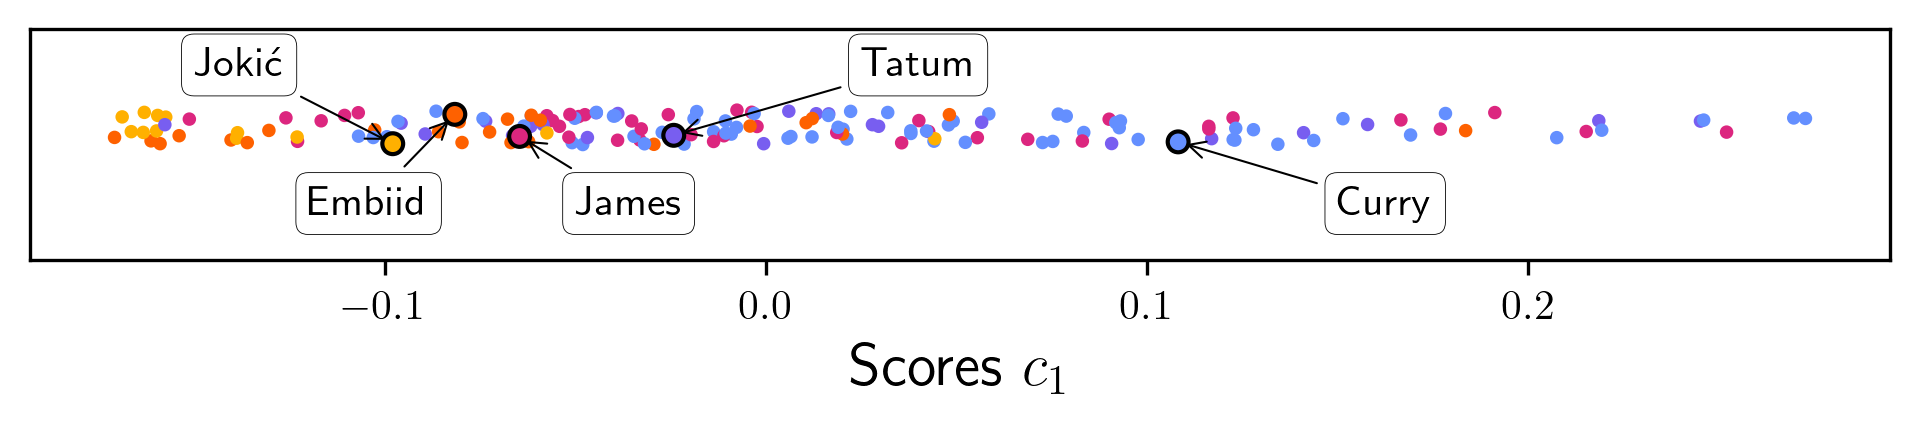

In [4]:
# First scores
COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

x = scores[0].values
y = np.repeat(0, len(scores)) + np.random.uniform(0, 3, size=len(scores))
c = scores['POSITION_'].map(COLORS)

fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 1),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax.scatter(x, y, c=c , s=5)
ax.scatter(
    x[[40, 153, 88, 49, 91]],
    y[[40, 153, 88, 49, 91]],
    c=c[[40, 153, 88, 49, 91]],
    edgecolors='black',
    s=25
)
ax.set_ylim(-10, 10)
ax.set_yticks([])

ax.annotate(  # Curry
    'Curry',
    xy=(x[40], y[40]), xycoords='data',
    xytext=(0.15, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Tatum
    'Tatum',
    xy=(x[153], y[153]), xycoords='data',
    xytext=(0.025, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # James
    'James',
    xy=(x[88], y[88]), xycoords='data',
    xytext=(-0.05, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Embiid
    'Embiid',
    xy=(x[49], y[49]), xycoords='data',
    xytext=(-0.12, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Jokic
    'Jokić',
    xy=(x[91], y[91]), xycoords='data',
    xytext=(-0.15, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.set_xlabel(f"Scores $c_1$", fontsize='x-large')

plt.savefig('./figures/scores_1.eps', transparent=True, format='eps', bbox_inches='tight', pad_inches=0.5)
plt.plot()

In [5]:
# Outliers in c1
print(f"MAX: {scores.iloc[np.argmax(scores[0])]['PLAYER_NAME']}")
print(f"MIN: {scores.iloc[np.argmin(scores[0])]['PLAYER_NAME']}")

MAX: Seth Curry
MIN: Mitchell Robinson


[]

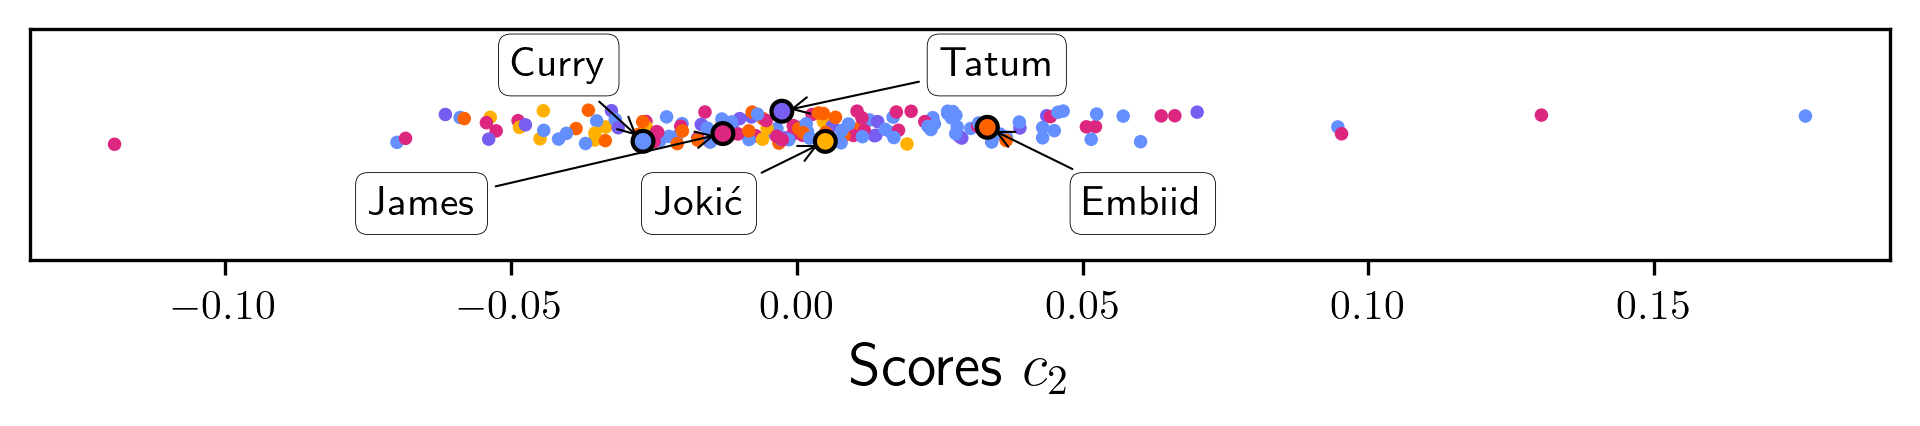

In [6]:
# Second scores
COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

x = scores[1].values
y = np.repeat(0, len(scores)) + np.random.uniform(0, 3, size=len(scores))
c = scores['POSITION_'].map(COLORS)

fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 1),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax.scatter(x, y, c=c , s=5)
ax.scatter(
    x[[40, 153, 88, 49, 91]],
    y[[40, 153, 88, 49, 91]],
    c=c[[40, 153, 88, 49, 91]],
    edgecolors='black',
    s=25
)
ax.set_ylim(-10, 10)
ax.set_yticks([])

ax.annotate(  # Curry
    'Curry',
    xy=(x[40], y[40]), xycoords='data',
    xytext=(-0.05, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Tatum
    'Tatum',
    xy=(x[153], y[153]), xycoords='data',
    xytext=(0.025, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # James
    'James',
    xy=(x[88], y[88]), xycoords='data',
    xytext=(-0.075, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Embiid
    'Embiid',
    xy=(x[49], y[49]), xycoords='data',
    xytext=(0.05, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Jokic
    'Jokić',
    xy=(x[91], y[91]), xycoords='data',
    xytext=(-0.025, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.set_xlabel(f"Scores $c_2$", fontsize='x-large')

plt.savefig('./figures/scores_2.eps', transparent=True, format='eps', bbox_inches='tight', pad_inches=0.5)
plt.plot()

In [7]:
# Outliers in c2
print(f"MAX: {scores.iloc[np.argmax(scores[1])]['PLAYER_NAME']}")
print(f"MIN: {scores.iloc[np.argmin(scores[1])]['PLAYER_NAME']}")

MAX: Chris Paul
MIN: Duncan Robinson


[]

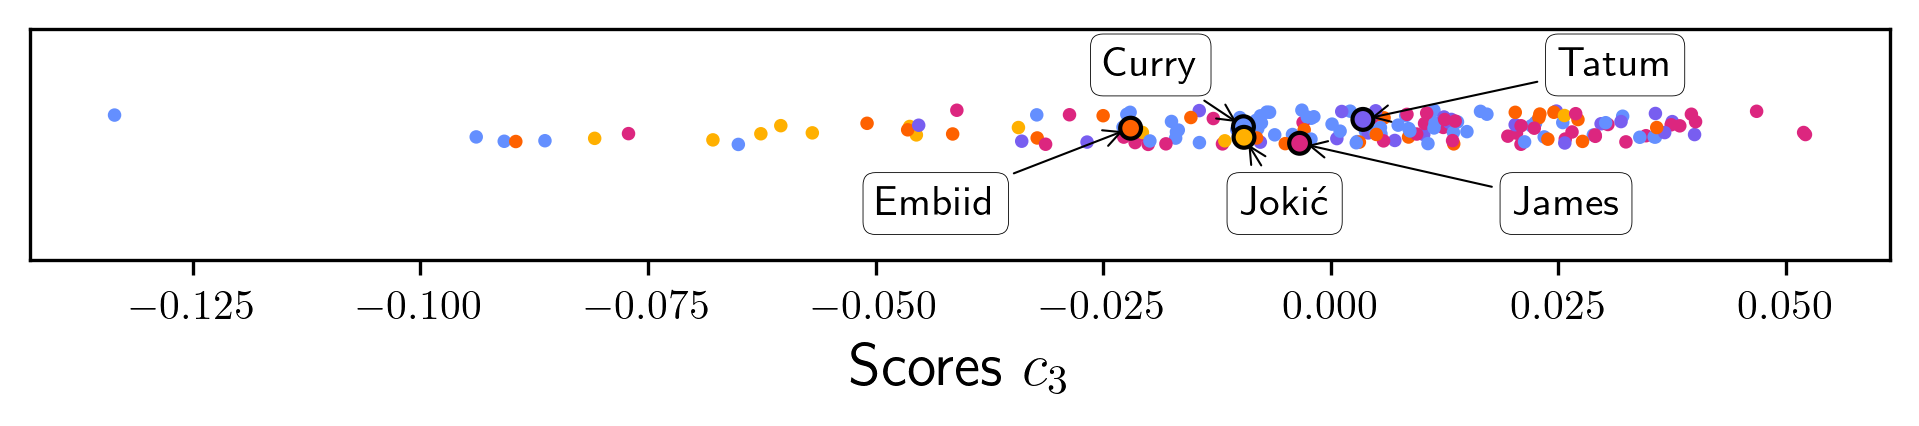

In [8]:
# Third scores
COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

x = scores[2].values
y = np.repeat(0, len(scores)) + np.random.uniform(0, 3, size=len(scores))
c = scores['POSITION_'].map(COLORS)

fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 1),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax.scatter(x, y, c=c , s=5)
ax.scatter(
    x[[40, 153, 88, 49, 91]],
    y[[40, 153, 88, 49, 91]],
    c=c[[40, 153, 88, 49, 91]],
    edgecolors='black',
    s=25
)
ax.set_ylim(-10, 10)
ax.set_yticks([])

ax.annotate(  # Curry
    'Curry',
    xy=(x[40], y[40]), xycoords='data',
    xytext=(-0.025, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Tatum
    'Tatum',
    xy=(x[153], y[153]), xycoords='data',
    xytext=(0.025, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # James
    'James',
    xy=(x[88], y[88]), xycoords='data',
    xytext=(0.02, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Embiid
    'Embiid',
    xy=(x[49], y[49]), xycoords='data',
    xytext=(-0.05, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Jokic
    'Jokić',
    xy=(x[91], y[91]), xycoords='data',
    xytext=(-0.01, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.set_xlabel(f"Scores $c_3$", fontsize='x-large')

plt.savefig('./figures/scores_3.eps', transparent=True, format='eps', bbox_inches='tight', pad_inches=0.5)
plt.plot()

In [9]:
# Outliers in c3
print(f"MIN: {scores.iloc[np.argmin(scores[2])]['PLAYER_NAME']}")
print(f"MAX: {scores.iloc[np.argmax(scores[2])]['PLAYER_NAME']}")

MIN: Chris Paul
MAX: Jeff Green


[]

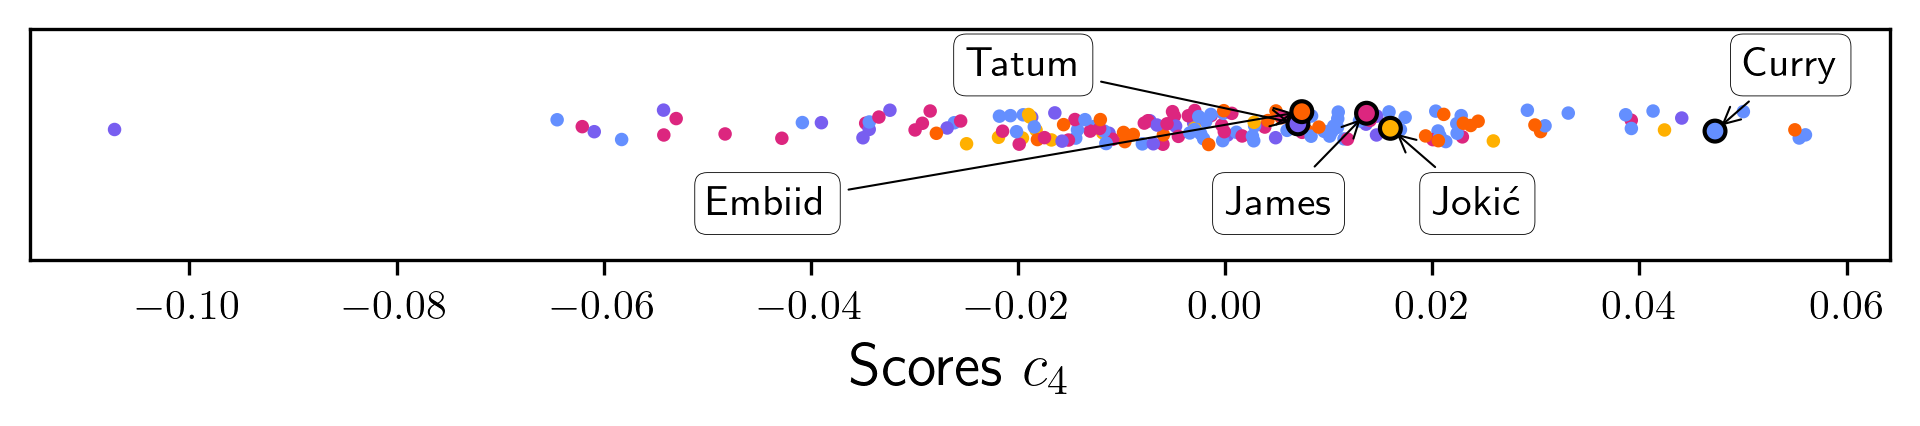

In [10]:
# Fourth scores
COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

x = scores[3].values
y = np.repeat(0, len(scores)) + np.random.uniform(0, 3, size=len(scores))
c = scores['POSITION_'].map(COLORS)

fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 1),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax.scatter(x, y, c=c , s=5)
ax.scatter(
    x[[40, 153, 88, 49, 91]],
    y[[40, 153, 88, 49, 91]],
    c=c[[40, 153, 88, 49, 91]],
    edgecolors='black',
    s=25
)
ax.set_ylim(-10, 10)
ax.set_yticks([])

ax.annotate(  # Curry
    'Curry',
    xy=(x[40], y[40]), xycoords='data',
    xytext=(0.05, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Tatum
    'Tatum',
    xy=(x[153], y[153]), xycoords='data',
    xytext=(-0.025, 6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # James
    'James',
    xy=(x[88], y[88]), xycoords='data',
    xytext=(0, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Embiid
    'Embiid',
    xy=(x[49], y[49]), xycoords='data',
    xytext=(-0.05, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.annotate(  # Jokic
    'Jokić',
    xy=(x[91], y[91]), xycoords='data',
    xytext=(0.02, -6), textcoords='data',
    bbox=dict(boxstyle="round", fc="w", linewidth=0.2),
    arrowprops=dict(arrowstyle="->", linewidth=0.5)
)
ax.set_xlabel(f"Scores $c_4$", fontsize='x-large')

plt.savefig('./figures/scores_4.eps', transparent=True, format='eps', bbox_inches='tight', pad_inches=0.5)
plt.plot()

In [11]:
# Outliers in c4
print(f"MAX: {scores.iloc[np.argmax(scores[3])]['PLAYER_NAME']}")
print(f"MIN: {scores.iloc[np.argmin(scores[3])]['PLAYER_NAME']}")

MAX: Kyle Lowry
MIN: Reggie Bullock Jr.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


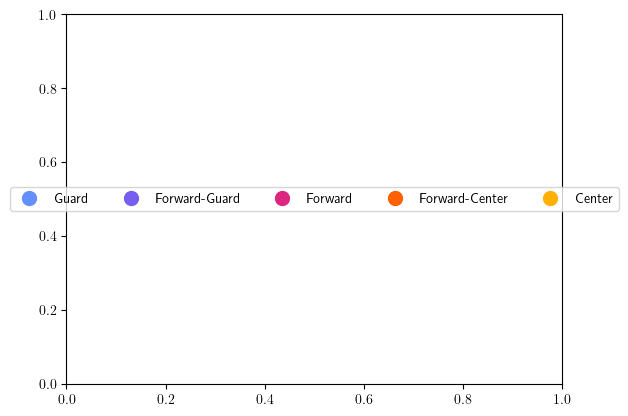

In [12]:
import matplotlib.lines as mlines

Gu = mlines.Line2D(
    [], [], color='#648FFF', marker='o', linestyle='None',
    markersize=10, label='Guard'
)
FG = mlines.Line2D(
    [], [], color='#785EF0', marker='o', linestyle='None',
    markersize=10, label='Forward-Guard'
)
Fo = mlines.Line2D(
    [], [], color='#DC267F', marker='o', linestyle='None',
    markersize=10, label='Forward'
)
FC = mlines.Line2D(
    [], [], color='#FE6100', marker='o', linestyle='None',
    markersize=10, label='Forward-Center'
)
Ce = mlines.Line2D(
    [], [], color='#FFB000', marker='o', linestyle='None',
    markersize=10, label='Center'
)

plt.legend(handles=[Gu, FG, Fo, FC, Ce], ncol=5, loc='center')

plt.savefig('./figures/legend.eps', transparent=True, format='eps', bbox_inches='tight', pad_inches=0.5)
plt.show()